In [1]:
import torch
import torch.nn as nn
import numpy as np
from pathlib import Path
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from src.data.tabular import split_data
from src.models.VAE import VariationalAutoencoder
from src.hpo.vae_autoencoder_hpo import create_study_vae
from src.hpo.hidden_dims import build_hidden_dims_geo, build_hidden_dims_static
from src.training.train_vae import train_final_model_vae
from src.metrics.knn import find_best_neighbors, compute_knn_score


h:\Course contents FAU\semester 5\Thesis\final Project\LatentDimAnalysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
digits = load_digits()
X = digits.data
X = StandardScaler().fit_transform(X)  
y = digits.target
X_train, X_val, X_test, y_train, y_val, y_test, encoder = split_data(X, y)
X_train_tensor = torch.from_numpy(X_train).float()
X_val_tensor   = torch.from_numpy(X_val).float()
X_test_tensor  = torch.from_numpy(X_test).float()

y_train_tensor = torch.from_numpy(y_train)
y_val_tensor = torch.from_numpy(y_val)
X_train_val_tensor = torch.cat([X_train_tensor, X_val_tensor], dim=0)
y_train_val_tensor = torch.cat([y_train_tensor, y_val_tensor], dim=0)
X_train_val = X_train_val_tensor.detach().cpu().numpy()
y_train_val = y_train_val_tensor.detach().cpu().numpy()

print("X_train, X_val , X_test split shape",X_train.shape, X_val.shape, X_test.shape)
print("X_train_val split shape", X_train_val.shape)
n_features = X_train.shape[1]

X_train, X_val , X_test split shape (1078, 64) (360, 64) (359, 64)
X_train_val split shape (1438, 64)


In [3]:
import torch

study = create_study_vae(
    X_train_tensor,
    X_val_tensor,
    n_epochs=2,
    bottleneck_dim=32,
    n_trials=20,
    study_name="vae_hpo_study"
)

print(len(study.trials))
print(study.best_value)
print(study.best_params)

[I 2026-09-10 01:02:49,434] A new study created in memory with name: vae_hpo_study
Best trial: 1. Best value: 1.13559:  25%|██▌       | 5/20 [00:03<00:08,  1.72it/s]

[I 2026-09-10 01:02:52,389] Trial 0 finished with value: 1.1400078535079956 and parameters: {'lr': 0.0001329291894316216, 'depth': 3, 'activation': 'ReLU', 'beta': 0.12389490049257872}. Best is trial 0 with value: 1.1400078535079956.
[I 2026-09-10 01:02:52,434] Trial 1 finished with value: 1.1355948448181152 and parameters: {'lr': 0.003967605077052989, 'depth': 2, 'activation': 'GELU', 'beta': 0.21886685320125288}. Best is trial 1 with value: 1.1355948448181152.
[I 2026-09-10 01:02:52,459] Trial 2 finished with value: 1.2468150854110718 and parameters: {'lr': 3.511356313970405e-05, 'depth': 1, 'activation': 'LeakyReLU', 'beta': 0.95548757341087}. Best is trial 1 with value: 1.1355948448181152.
[I 2026-09-10 01:02:52,491] Trial 3 finished with value: 1.207338809967041 and parameters: {'lr': 2.621087878265438e-05, 'depth': 1, 'activation': 'GELU', 'beta': 0.6665525894785898}. Best is trial 1 with value: 1.1355948448181152.
[I 2026-09-10 01:02:52,519] Trial 4 finished with value: 1.361607

Best trial: 10. Best value: 1.06305:  55%|█████▌    | 11/20 [00:03<00:01,  6.05it/s]

[I 2026-09-10 01:02:52,576] Trial 6 finished with value: 1.1438900232315063 and parameters: {'lr': 1.2681352169084594e-05, 'depth': 3, 'activation': 'LeakyReLU', 'beta': 0.7513852499152172}. Best is trial 1 with value: 1.1355948448181152.
[I 2026-09-10 01:02:52,608] Trial 7 finished with value: 1.1570008993148804 and parameters: {'lr': 3.585612610345396e-05, 'depth': 3, 'activation': 'LeakyReLU', 'beta': 2.9984570265055073}. Best is trial 1 with value: 1.1355948448181152.
[I 2026-09-10 01:02:52,640] Trial 8 pruned. 
[I 2026-09-10 01:02:52,665] Trial 9 pruned. 
[I 2026-09-10 01:02:52,726] Trial 10 finished with value: 1.0630488395690918 and parameters: {'lr': 0.008109423198488348, 'depth': 2, 'activation': 'Tanh', 'beta': 0.10685036309142656}. Best is trial 10 with value: 1.0630488395690918.


Best trial: 11. Best value: 1.05055:  75%|███████▌  | 15/20 [00:03<00:00,  8.18it/s]

[I 2026-09-10 01:02:52,773] Trial 11 finished with value: 1.0505536794662476 and parameters: {'lr': 0.009107095061877632, 'depth': 2, 'activation': 'Tanh', 'beta': 0.1062027190453869}. Best is trial 11 with value: 1.0505536794662476.
[I 2026-09-10 01:02:52,829] Trial 12 finished with value: 1.0524485111236572 and parameters: {'lr': 0.008878208292622385, 'depth': 2, 'activation': 'Tanh', 'beta': 0.10179668047209123}. Best is trial 11 with value: 1.0505536794662476.
[I 2026-09-10 01:02:52,863] Trial 13 pruned. 
[I 2026-09-10 01:02:52,909] Trial 14 finished with value: 1.0625532865524292 and parameters: {'lr': 0.009659243864645024, 'depth': 2, 'activation': 'Tanh', 'beta': 0.21075816443954515}. Best is trial 11 with value: 1.0505536794662476.
[I 2026-09-10 01:02:52,941] Trial 15 pruned. 


Best trial: 17. Best value: 1.04645: 100%|██████████| 20/20 [00:03<00:00,  5.50it/s]

[I 2026-09-10 01:02:52,974] Trial 16 finished with value: 1.1383875608444214 and parameters: {'lr': 0.0039228779121567615, 'depth': 2, 'activation': 'ReLU', 'beta': 0.3541481885836765}. Best is trial 11 with value: 1.0505536794662476.
[I 2026-09-10 01:02:53,024] Trial 17 finished with value: 1.0464500188827515 and parameters: {'lr': 0.009366988200274384, 'depth': 2, 'activation': 'Tanh', 'beta': 0.10089159515395636}. Best is trial 17 with value: 1.0464500188827515.
[I 2026-09-10 01:02:53,058] Trial 18 pruned. 
[I 2026-09-10 01:02:53,104] Trial 19 pruned. 
20
1.0464500188827515
{'lr': 0.009366988200274384, 'depth': 2, 'activation': 'Tanh', 'beta': 0.10089159515395636}


In [4]:
vae_total_loss = []
vae_recon_loss = []
vae_kl_loss =[]
pca_errors = []
vae_knn = []
pca_knn = []
bottleneck_range = [1, 2, 4, 8, 16, 32, 62]
input_dim = X_train_val_tensor.shape[1]

best_params_vae = study.best_params

activations = {
    "ReLU": nn.ReLU,
    "LeakyReLU": nn.LeakyReLU,
    "GELU": nn.GELU,
    "Tanh": nn.Tanh
}

best_activation_vae = activations[
    best_params_vae["activation"]
]

best_neighbors, best_val_score = find_best_neighbors(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val
)

print("Best neighbors:", best_neighbors)
print("Validation accuracy:", best_val_score)

best_depth_vae = best_params_vae["depth"]
best_beta_vae = best_params_vae["beta"]
best_lr_vae = best_params_vae["lr"]

print("Best VAE params:", best_params_vae)


for k in bottleneck_range:

    # Same hidden-layer rule as used during HPO
    final_hidden_dims_vae = build_hidden_dims_static(
        input_dim,
        depth=best_depth_vae
    )

    pca = PCA(n_components=k)
    X_reduced_pca = pca.fit_transform(X_train_val)
    X_test_reduced_pca = pca.transform(X_test)
    X_recon_pca = pca.inverse_transform(X_reduced_pca)

    pca_knn_accuracy = compute_knn_score(
            X_train=X_reduced_pca,
            y_train=y_train_val,
            X_test=X_test_reduced_pca,
            y_test=y_test,
            n_neighbors=best_neighbors
    )

    pca_errors.append(np.mean((X_train_val - X_recon_pca) ** 2))
    pca_knn.append(pca_knn_accuracy)

    # ==========================================
    # Create final VAE
    # ==========================================
    final_vae = VariationalAutoencoder(
        n_features=input_dim,
        bottleneck_dim=k,
        hidden_dims_list=final_hidden_dims_vae,
        non_linear_function=best_activation_vae
    )

    # ==========================================
    # Train final VAE
    # ==========================================
    train_loss, test_loss, recon_loss, kl_loss, mu_train_val, mu_test = train_final_model_vae(
        final_model=final_vae,
        X_train_val_tensor=X_train_val_tensor,
        X_test_tensor=X_test_tensor,
        best_params=best_params_vae,
        epochs=400
    )

    # Convert latent means to numpy
    mu_train_val = mu_train_val.cpu().numpy()
    mu_test = mu_test.cpu().numpy()

    # ==========================================
    # KNN evaluation
    # ==========================================
    vae_knn_accuracy = compute_knn_score(
        X_train=mu_train_val,
        y_train=y_train_val,
        X_test=mu_test,
        y_test=y_test,
        n_neighbors=best_neighbors
    )

    vae_knn.append(vae_knn_accuracy)
    vae_total_loss.append(train_loss)
    vae_recon_loss.append(recon_loss)
    vae_kl_loss.append(kl_loss)

    print(
        f"k={k:>3} "
        f"VAE KNN={vae_knn_accuracy:.4f} "
        f"VAE Loss={train_loss:.4f} "
        f"Test Loss={test_loss:.4f}"
    )

Best neighbors: 5
Validation accuracy: 0.9583333333333334
Best VAE params: {'lr': 0.009366988200274384, 'depth': 2, 'activation': 'Tanh', 'beta': 0.10089159515395636}
k=  1 VAE KNN=0.4039 VAE Loss=0.8755 Test Loss=0.8333
k=  2 VAE KNN=0.7242 VAE Loss=0.6204 Test Loss=0.6266
k=  4 VAE KNN=0.8774 VAE Loss=0.4126 Test Loss=0.4593
k=  8 VAE KNN=0.8830 VAE Loss=0.3099 Test Loss=0.3593
k= 16 VAE KNN=0.9192 VAE Loss=0.2333 Test Loss=0.2854
k= 32 VAE KNN=0.8245 VAE Loss=0.1748 Test Loss=0.2229
k= 62 VAE KNN=0.7744 VAE Loss=0.1338 Test Loss=0.1784


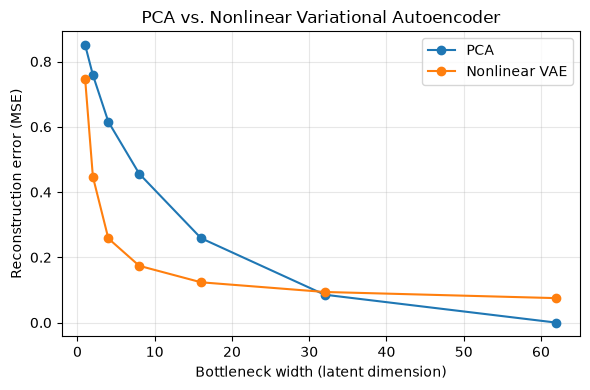

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(bottleneck_range, pca_errors, marker="o", label="PCA")
plt.plot(bottleneck_range, vae_recon_loss, marker="o", label="Nonlinear VAE")
plt.xlabel("Bottleneck width (latent dimension)")
plt.ylabel("Reconstruction error (MSE)")
plt.title("PCA vs. Nonlinear Variational Autoencoder")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

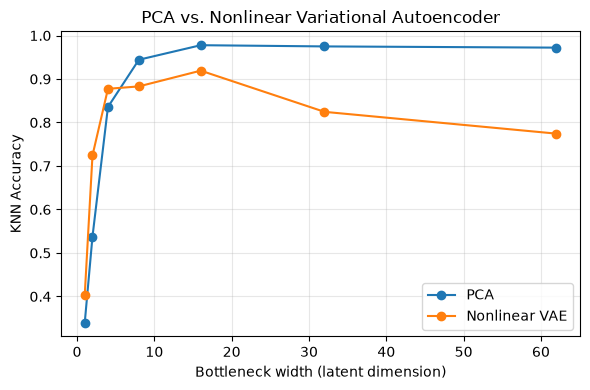

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(bottleneck_range, pca_knn, marker="o", label="PCA")
plt.plot(bottleneck_range, vae_knn, marker="o", label="Nonlinear VAE")
plt.xlabel("Bottleneck width (latent dimension)")
plt.ylabel("KNN Accuracy")
plt.title("PCA vs. Nonlinear Variational Autoencoder")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()